# MEEP L3 Cavity Simulation

This notebook simulates an L3 photonic crystal cavity using MEEP, parallel to the Legume GME implementation.

## Computing band structure

STEP 1: Computing band structure of perfect PhC
Computing 10 bands along 126 k-points...
Initializing eigensolver data
Computing 10 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 24 x 24 x 1.
Solving for 10 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0.5, 0.866025, 0)
     (0, 0, 1)
Cell volume = 0.866025
Reciprocal lattice vectors (/ 2 pi):
     (1, -0.57735, 0)
     (-0, 1.1547, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1e+20,1e+20,0.5)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.3, height 0.5, axis (0, 0, 1)
Geometric object tree has depth 1 and 10 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: te.
Initializing fields to random numbers...
126 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.012195121951219513, 0.0, 0.0>
  Vector3<0.024390243902439025, 0.0,

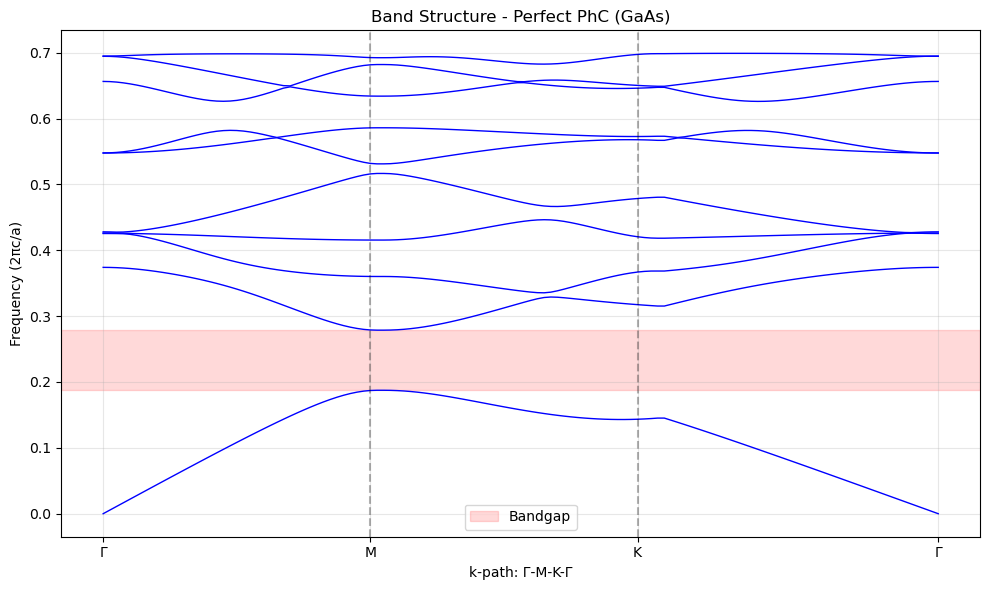

In [22]:
import meep as mp
from meep import mpb
import numpy as np
import matplotlib.pyplot as plt

# ========== Parameters ==========
# PhC parameters (matching Legume simulation)
ra = 0.3          # hole radius in units of lattice constant a
dslab = 0.5       # slab thickness
n_slab = 3.4      # GaAs refractive index

# ========== Step 1: Band Structure of Perfect PhC ==========
print("=" * 60)
print("STEP 1: Computing band structure of perfect PhC")
print("=" * 60)

# Lattice geometry - triangular lattice
geometry_lattice = mp.Lattice(
    size=mp.Vector3(1, 1),
    basis1=mp.Vector3(1, 0),
    basis2=mp.Vector3(0.5, np.sqrt(3)/2)
)

# Single unit cell with hole
geometry = [
    mp.Block(
        material=mp.Medium(epsilon=n_slab**2),
        size=mp.Vector3(mp.inf, mp.inf, dslab),
        center=mp.Vector3(0, 0, 0)
    ),
    mp.Cylinder(
        radius=ra,
        height=dslab,
        center=mp.Vector3(0, 0, 0),
        material=mp.air
    )
]

# Resolution (grid points per lattice constant)
resolution = 24

# Number of bands to compute
num_bands = 10

# Create MPB simulation
ms = mpb.ModeSolver(
    geometry_lattice=geometry_lattice,
    geometry=geometry,
    resolution=resolution,
    num_bands=num_bands
)

# Define high-symmetry k-points: Γ-M-K-Γ for triangular lattice
Gamma = mp.Vector3(0, 0, 0)
M = mp.Vector3(0.5, 0, 0)
K = mp.Vector3(1/3, 1/3, 0)

k_points = mp.interpolate(40, [Gamma, M]) + \
           mp.interpolate(40, [M, K]) + \
           mp.interpolate(40, [K, Gamma])

# Run band structure calculation along the k-path
print(f"Computing {num_bands} bands along {len(k_points)} k-points...")

# Set k-points and run
ms.k_points = k_points
freqs = ms.run_te()

# Manually find bandgap from computed frequencies
# Convert all_freqs to numpy array for easier manipulation
all_freqs_array = np.array(ms.all_freqs)  # shape: (n_kpoints, n_bands)

print(f"\nAnalyzing bands for gaps...")
print(f"Frequency range: {all_freqs_array.min():.4f} - {all_freqs_array.max():.4f}")

# Find gaps between consecutive bands
bandgap = None
for i in range(num_bands - 1):
    band_top = np.max(all_freqs_array[:, i])
    band_bottom = np.min(all_freqs_array[:, i + 1])
    
    if band_bottom > band_top:
        gap_size = band_bottom - band_top
        gap_center = (band_top + band_bottom) / 2
        gap_percent = gap_size / gap_center * 100
        
        print(f"  Gap between bands {i+1}-{i+2}: {gap_percent:.2f}% at freq {gap_center:.4f}")
        print(f"    Lower edge: {band_top:.4f}, Upper edge: {band_bottom:.4f}")
        
        if bandgap is None or gap_size > bandgap['size']:
            bandgap = {
                'lower': band_top,
                'upper': band_bottom,
                'size': gap_size,
                'center': gap_center,
                'bands': (i, i+1)
            }

if bandgap is not None:
    f_lb = bandgap['lower']
    f_ub = bandgap['upper']
    f_target = bandgap['center']
    
    print(f"\nUsing largest bandgap:")
    print(f"  Lower edge: {f_lb:.4f}")
    print(f"  Upper edge: {f_ub:.4f}")
    print(f"  Center: {f_target:.4f}")
else:
    print("\nNo complete bandgap found, using default values")
    f_lb = 0.26
    f_ub = 0.33
    f_target = 0.28

# Plot band structure
fig, ax = plt.subplots(figsize=(10, 6))
for band in range(num_bands):
    band_freqs = all_freqs_array[:, band]
    ax.plot(band_freqs, 'b-', linewidth=1)

ax.set_xlabel('k-path: Γ-M-K-Γ')
ax.set_ylabel('Frequency (2πc/a)')
ax.set_title('Band Structure - Perfect PhC (GaAs)')
ax.grid(True, alpha=0.3)

# Mark high-symmetry points
n_GM = 40
n_MK = 40
ax.axvline(x=n_GM, color='k', linestyle='--', alpha=0.3)
ax.axvline(x=n_GM + n_MK, color='k', linestyle='--', alpha=0.3)
ax.set_xticks([0, n_GM, n_GM + n_MK, len(k_points)-1])
ax.set_xticklabels(['Γ', 'M', 'K', 'Γ'])

# Shade bandgap if found
if bandgap is not None:
    ax.axhspan(f_lb, f_ub, alpha=0.15, color='red', label='Bandgap')
    ax.legend()

plt.tight_layout()
plt.show()

## Adding L3 Cavity and computing modes

Building L3 cavity geometry
  Supercell: 15x9 (15.0 x 7.79 lattice constants)
  Slab: thickness=0.5, n=3.4, eps=11.6
  Holes: 132 (3 removed for L3 cavity)
  End-hole shift: 0.15a
  Resolution: 24 pixels/a
  PML: 1.0a in all directions
  Symmetries: Mirror(X), Mirror(Y), Mirror(Z) -> 8x speedup
     block, center = (0,0,0)
          size (15,7.79423,0.5)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (11.56,11.56,11.56)
     cylinder, center = (-7.5,-3.89711,0)
          radius 0.3, height 0.5, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-6.5,-3.89711,0)
          radius 0.3, height 0.5, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-5.5,-3.89711,0)
          radius 0.3, height 0.5, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-4.5,-3.89711,0)
          radius 0.3, height 0.5, axis (0, 0, 1

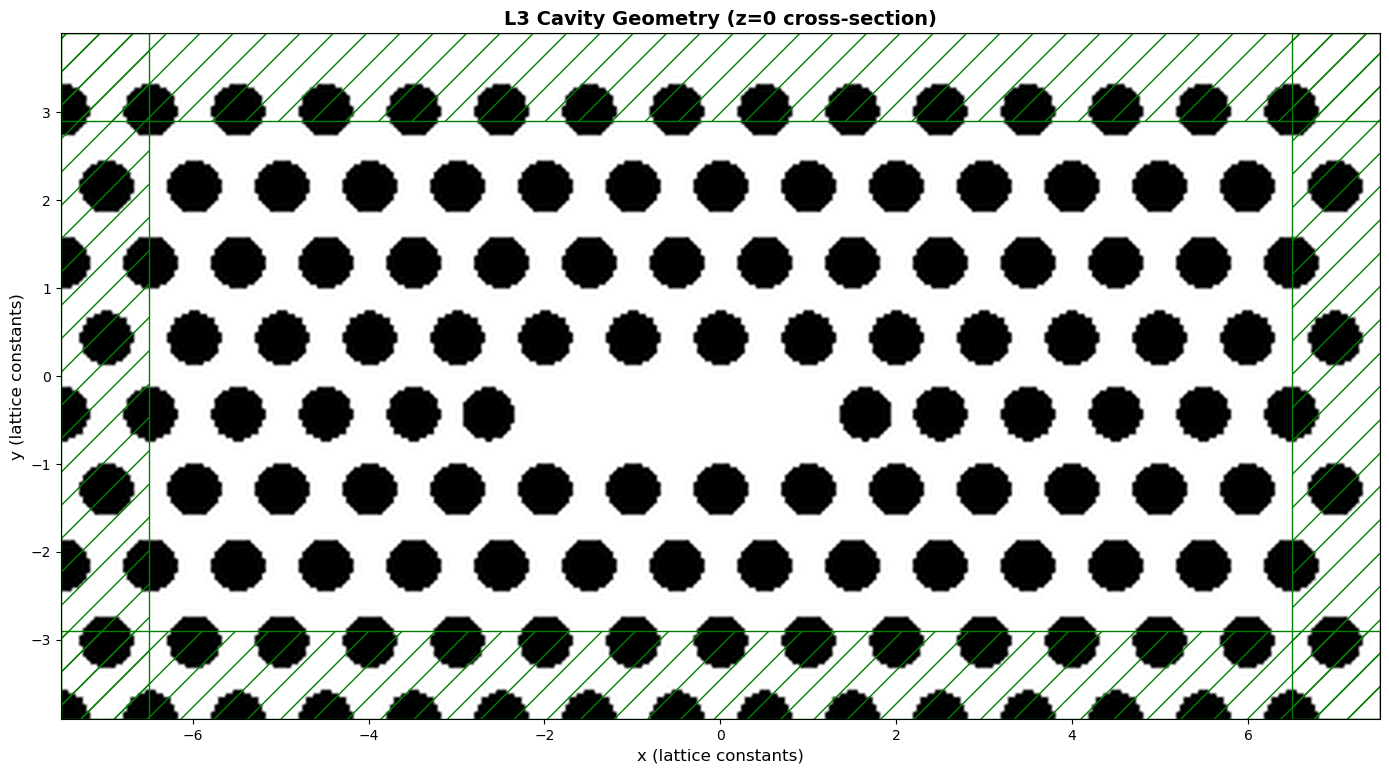

In [23]:
# ========== Build L3 Cavity Geometry ==========
print("=" * 60)
print("Building L3 cavity geometry")
print("=" * 60)

# L3 cavity parameters
end_hole_shift = 0.15  # shift end holes outward to boost Q

# Supercell size (in lattice constants)
Nx, Ny = 15, 9
sx = Nx
sy = Ny * np.sqrt(3) / 2
sz = 6  # computational cell height (includes PML)

# Create triangular lattice with L3 cavity
geometry = []

# Add slab
geometry.append(
    mp.Block(
        material=mp.Medium(epsilon=n_slab**2),
        size=mp.Vector3(sx, sy, dslab),
        center=mp.Vector3(0, 0, 0)
    )
)

# Add holes in triangular lattice pattern (except L3 cavity)
removed_ix = {Nx//2 - 1, Nx//2, Nx//2 + 1}
left_end_ix = Nx//2 - 2
right_end_ix = Nx//2 + 2
cavity_iy = Ny // 2

for iy in range(Ny):
    for ix in range(Nx):
        x = ix + (iy % 2) * 0.5 - Nx/2
        y = (iy - Ny/2) * np.sqrt(3) / 2
        
        # Skip 3 holes to form L3 cavity
        if iy == cavity_iy and ix in removed_ix:
            continue
        
        # Shift end holes outward to boost Q
        if iy == cavity_iy and ix == left_end_ix:
            x -= end_hole_shift
        elif iy == cavity_iy and ix == right_end_ix:
            x += end_hole_shift
        
        geometry.append(
            mp.Cylinder(
                radius=ra,
                height=dslab,
                center=mp.Vector3(x, y, 0),
                material=mp.air
            )
        )

# Simulation parameters
cell_size = mp.Vector3(sx, sy, sz)
pml_layers = [mp.PML(thickness=1.0)]
resolution = 24

# All 3 mirror symmetries for 8x speedup (selects fundamental L3 mode)
symmetries = [
    mp.Mirror(mp.X, phase=+1),   # Ey even in x
    mp.Mirror(mp.Y, phase=-1),   # Ey even in y (phase=-1 because Ey vector flips under y-mirror)
    mp.Mirror(mp.Z, phase=+1),   # TE-like: Ey even in z
]

# Print geometry summary
n_holes = len(geometry) - 1  # subtract slab block
print(f"  Supercell: {Nx}x{Ny} ({sx:.1f} x {sy:.2f} lattice constants)")
print(f"  Slab: thickness={dslab}, n={n_slab}, eps={n_slab**2:.1f}")
print(f"  Holes: {n_holes} (3 removed for L3 cavity)")
print(f"  End-hole shift: {end_hole_shift}a")
print(f"  Resolution: {resolution} pixels/a")
print(f"  PML: 1.0a in all directions")
print(f"  Symmetries: Mirror(X), Mirror(Y), Mirror(Z) -> 8x speedup")

# Plot the geometry (no simulation needed)
sim_check = mp.Simulation(
    cell_size=cell_size,
    geometry=geometry,
    boundary_layers=pml_layers,
    resolution=resolution
)

fig, ax = plt.subplots(figsize=(14, 8))
sim_check.plot2D(
    ax=ax,
    output_plane=mp.Volume(center=mp.Vector3(0, 0, 0), size=mp.Vector3(sx, sy, 0)),
    eps_parameters={'cmap': 'binary_r', 'interpolation': 'spline36'}
)
ax.set_title('L3 Cavity Geometry (z=0 cross-section)', fontsize=14, fontweight='bold')
ax.set_xlabel('x (lattice constants)', fontsize=12)
ax.set_ylabel('y (lattice constants)', fontsize=12)
plt.tight_layout()
plt.show()

In [29]:
# ========== Step 2: L3 Cavity Mode Finding ==========
# Reuses geometry, cell_size, pml_layers, resolution, symmetries from geometry cell above
print("\n" + "=" * 60)
print("STEP 2: Computing L3 cavity modes")
print("=" * 60)

# Source: Gaussian pulse centered in bandgap
fcen = f_target
df = f_ub - f_lb

# Place source slightly off-center to avoid potential nodal point at exact origin
sources = [
    mp.Source(
        mp.GaussianSource(fcen, fwidth=df),
        component=mp.Ey,
        center=mp.Vector3(0.1, 0, 0)
    )
]

# Create simulation using variables from geometry cell
sim = mp.Simulation(
    cell_size=cell_size,
    geometry=geometry,
    sources=sources,
    boundary_layers=pml_layers,
    resolution=resolution,
    symmetries=symmetries
)

# Harminv monitor also slightly off-center to avoid nodal points
h = mp.Harminv(mp.Ey, mp.Vector3(0.1, 0, 0), fcen, df)

print(f"  Frequency range: {fcen-df/2:.4f} - {fcen+df/2:.4f} (center: {fcen:.4f})")
print(f"  Supercell: {Nx}x{Ny}, resolution: {resolution}")
print(f"  Running Harminv analysis (until_after_sources=400)...")

sim.run(mp.after_sources(h), until_after_sources=200)

# Extract resonant modes
modes = h.modes

print(f"\nFound {len(modes)} resonant modes:")
for i, mode in enumerate(modes):
    in_gap = f_lb < mode.freq < f_ub
    marker = " <-- IN BANDGAP" if in_gap else ""
    print(f"  Mode {i}: f = {mode.freq:.4f}, Q = {mode.Q:.1f}{marker}")

cavity_modes = modes


STEP 2: Computing L3 cavity modes
  Frequency range: 0.1874 - 0.2787 (center: 0.2331)
  Supercell: 15x9, resolution: 24
  Running Harminv analysis (until_after_sources=400)...
-----------
Initializing structure...
Padding y to even number of grid points.
Halving computational cell along direction x
Halving computational cell along direction y
Halving computational cell along direction z
time for choose_chunkdivision = 0.00231004 s
Working in 3D dimensions.
Computational cell is 15 x 7.79167 x 6 with resolution 24
     block, center = (0,0,0)
          size (15,7.79423,0.5)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (11.56,11.56,11.56)
     cylinder, center = (-7.5,-3.89711,0)
          radius 0.3, height 0.5, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-6.5,-3.89711,0)
          radius 0.3, height 0.5, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder

FloatProgress(value=0.0, description='0% done ', max=309.56180572509766)

Meep progress: 4.833333333333333/309.56180572509766 = 1.6% done in 4.0s, 252.4s to go
on time step 233 (time=4.85417), 0.0172408 s/step
Meep progress: 9.395833333333332/309.56180572509766 = 3.0% done in 8.0s, 255.7s to go
on time step 452 (time=9.41667), 0.018282 s/step
Meep progress: 13.958333333333332/309.56180572509766 = 4.5% done in 12.0s, 254.3s to go
on time step 671 (time=13.9792), 0.0182799 s/step
Meep progress: 18.541666666666664/309.56180572509766 = 6.0% done in 16.0s, 251.3s to go
on time step 892 (time=18.5833), 0.018175 s/step
Meep progress: 23.479166666666664/309.56180572509766 = 7.6% done in 20.0s, 244.0s to go
on time step 1129 (time=23.5208), 0.0169128 s/step
Meep progress: 28.291666666666664/309.56180572509766 = 9.1% done in 24.0s, 238.9s to go
on time step 1360 (time=28.3333), 0.0173593 s/step
Meep progress: 33.229166666666664/309.56180572509766 = 10.7% done in 28.0s, 233.2s to go
on time step 1597 (time=33.2708), 0.0169053 s/step
Meep progress: 39.479166666666664/30

## Visualizing cavity mode fields

In [31]:
# ========== Step 3: Field Visualization ==========
print("\n" + "=" * 60)
print("STEP 3: Visualizing cavity mode fields")
print("=" * 60)

# Select modes in bandgap
bandgap_modes = [(i, m) for i, m in enumerate(cavity_modes) if f_lb < m.freq < f_ub]

if bandgap_modes:
    print(f"Found {len(bandgap_modes)} modes in bandgap. Plotting all...")
    
    # Plot |Ey| for each mode in bandgap
    for mode_idx, mode in bandgap_modes:
        print(f"\nVisualizing mode {mode_idx}: f = {mode.freq:.4f}, Q = {mode.Q:.1f}")
        
        # ContinuousSource at the resonance frequency
        sources = [
            mp.Source(
                mp.ContinuousSource(frequency=mode.freq, width=5, is_integrated=True),
                component=mp.Ey,
                center=mp.Vector3(0.1, 0, 0)
            )
        ]
        
        sim = mp.Simulation(
            cell_size=cell_size,
            geometry=geometry,
            sources=sources,
            boundary_layers=pml_layers,
            resolution=resolution,
            symmetries=symmetries
        )
        
        # Run until fields reach steady state
        print(f"  Running simulation to steady state...")
        sim.run(until_after_sources=mp.stop_when_fields_decayed(
            50, mp.Ey, mp.Vector3(0.1, 0, 0), 0.98
        ))
        print(f"  Converged at t = {sim.meep_time():.1f}")
        
        # Get Ey field component at z=0
        ey_data = sim.get_array(center=mp.Vector3(0, 0, 0), size=mp.Vector3(sx, sy, 0), component=mp.Ey)
        
        # Plot |Ey|
        fig, ax = plt.subplots(figsize=(12, 7))
        field_mag = np.abs(ey_data).T
        im = ax.imshow(field_mag, cmap='hot', origin='lower',
                      extent=[-sx/2, sx/2, -sy/2, sy/2], 
                      interpolation='bilinear', aspect='auto')
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('|Ey|', rotation=270, labelpad=20)
        ax.set_title(f'|Ey| - Mode {mode_idx}: f = {mode.freq:.4f}, Q = {mode.Q:.0f}', 
                    fontsize=14, fontweight='bold')
        ax.set_xlabel('x (lattice constants)', fontsize=12)
        ax.set_ylabel('y (lattice constants)', fontsize=12)
        ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
        plt.tight_layout()
        plt.show()
        
else:
    print("No modes found in bandgap to visualize")


STEP 3: Visualizing cavity mode fields
Found 1 modes in bandgap. Plotting all...

Visualizing mode 0: f = 0.2561, Q = 348.7
  Running simulation to steady state...
-----------
Initializing structure...
Padding y to even number of grid points.
Halving computational cell along direction x
Halving computational cell along direction y
Halving computational cell along direction z
time for choose_chunkdivision = 0.00202489 s
Working in 3D dimensions.
Computational cell is 15 x 7.79167 x 6 with resolution 24
     block, center = (0,0,0)
          size (15,7.79423,0.5)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (11.56,11.56,11.56)
     cylinder, center = (-7.5,-3.89711,0)
          radius 0.3, height 0.5, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-6.5,-3.89711,0)
          radius 0.3, height 0.5, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (

KeyboardInterrupt: 

## Detailed signed field visualization for chosen mode

In [ ]:
# ========== Detailed Field Visualization with Sign ==========
print("=" * 60)
print("Plotting real and imaginary fields for chosen mode")
print("=" * 60)

# User selects mode by index
mode_to_plot = 0  # Change this to the desired mode index

# Verify mode exists
if mode_to_plot < len(cavity_modes):
    selected_mode = cavity_modes[mode_to_plot]
    
    print(f"Plotting mode {mode_to_plot}: f = {selected_mode.freq:.4f}, Q = {selected_mode.Q:.1f}")
    
    sources = [
        mp.Source(
            mp.ContinuousSource(frequency=selected_mode.freq, width=5, is_integrated=True),
            component=mp.Ey,
            center=mp.Vector3(0.1, 0, 0)
        )
    ]
    
    sim = mp.Simulation(
        cell_size=cell_size,
        geometry=geometry,
        sources=sources,
        boundary_layers=pml_layers,
        resolution=resolution,
        symmetries=symmetries
    )
    
    print("Running simulation to steady state...")
    sim.run(until_after_sources=mp.stop_when_fields_decayed(
        50, mp.Ey, mp.Vector3(0.1, 0, 0), 1e-3
    ))
    print(f"Converged at t = {sim.meep_time():.1f}")
    
    # Get field components (complex)
    ex_data = sim.get_array(center=mp.Vector3(0, 0, 0), size=mp.Vector3(sx, sy, 0), component=mp.Ex)
    ey_data = sim.get_array(center=mp.Vector3(0, 0, 0), size=mp.Vector3(sx, sy, 0), component=mp.Ey)
    ez_data = sim.get_array(center=mp.Vector3(0, 0, 0), size=mp.Vector3(sx, sy, 0), component=mp.Ez)
    
    components_data = [('x', ex_data), ('y', ey_data), ('z', ez_data)]
    
    for comp_name, data in components_data:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        
        # Real part
        real_data = np.real(data).T
        vmax = np.abs(real_data).max()
        if vmax > 0:
            im1 = ax1.imshow(real_data, cmap='RdBu_r', origin='lower',
                          extent=[-sx/2, sx/2, -sy/2, sy/2], 
                          interpolation='bilinear', vmin=-vmax, vmax=vmax, aspect='auto')
            ax1.set_title(f'Re(E_{comp_name})', fontsize=12, fontweight='bold')
            ax1.set_xlabel('x (lattice constants)', fontsize=10)
            ax1.set_ylabel('y (lattice constants)', fontsize=10)
            ax1.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)
            cbar1 = plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
            cbar1.set_label(f'Re(E_{comp_name})', rotation=270, labelpad=15)
        
        # Imaginary part
        imag_data = np.imag(data).T
        vmax = np.abs(imag_data).max()
        if vmax > 0:
            im2 = ax2.imshow(imag_data, cmap='RdBu_r', origin='lower',
                          extent=[-sx/2, sx/2, -sy/2, sy/2], 
                          interpolation='bilinear', vmin=-vmax, vmax=vmax, aspect='auto')
            ax2.set_title(f'Im(E_{comp_name})', fontsize=12, fontweight='bold')
            ax2.set_xlabel('x (lattice constants)', fontsize=10)
            ax2.set_ylabel('y (lattice constants)', fontsize=10)
            ax2.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)
            cbar2 = plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
            cbar2.set_label(f'Im(E_{comp_name})', rotation=270, labelpad=15)
        
        fig.suptitle(f'Mode {mode_to_plot}: f={selected_mode.freq:.4f}, Q={selected_mode.Q:.0f}',
                    fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
else:
    print(f"Mode {mode_to_plot} does not exist. Available modes: 0-{len(cavity_modes)-1}")